# Homework 1 Solution

In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
sns.set_palette("husl")
plt.rcParams.update(
    {
        "figure.facecolor": "#111111",
        "axes.facecolor": "#111111",
        "axes.edgecolor": "#aaaaaa",
        "text.color": "#ffffff",
        "xtick.color": "#aaaaaa",
        "ytick.color": "#aaaaaa",
    }
)

os.makedirs("./figures", exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
from numpy.typing import NDArray
from scipy.stats import gaussian_kde

df = pd.read_csv(
    "https://raw.githubusercontent.com/tobiasdelpozo/data-analysis-2026/"
    "refs/heads/master/homework/homework_1/questions/homework_1_data.csv"
)
df.head()

,X1,X2,X3,target,y
0,10.305440,5.618102,4.706610,0.114412,1.788909
1,12.921250,14.260715,11.947028,-0.382510,2.500579
2,4.142842,10.979909,9.198507,1.173814,6.175306
3,12.113707,8.979877,7.522964,0.407329,8.815286
4,5.738467,2.340280,1.960588,2.109283,8.717354


## Problem 1

### 1.1

In [3]:
x1 = df["X1"]
stats_1_1 = pd.Series(
    {"mean": x1.mean(), "median": x1.median(), "variance": x1.var(), "std": x1.std()},
    name="Value",
)
print(stats_1_1.to_latex(float_format="{:0.4f}".format))

\begin{tabular}{lr}
\toprule
 & Value \\
\midrule
mean & 12.3435 \\
median & 11.9216 \\
variance & 38.8894 \\
std & 6.2361 \\
\bottomrule
\end{tabular}



### 1.2

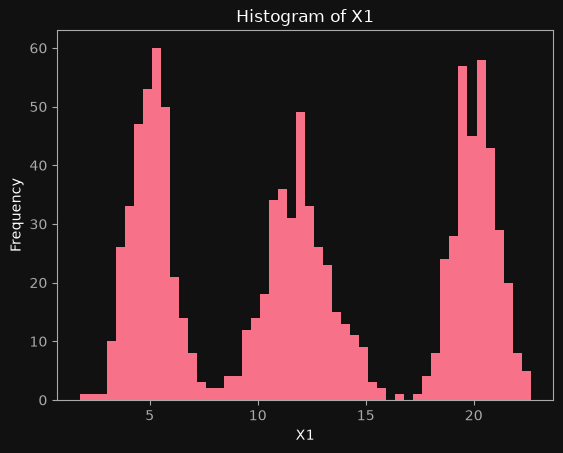

In [4]:
ax = x1.plot.hist(bins=50, xlabel="X1", ylabel="Frequency", title="Histogram of X1")
ax.figure.savefig("./figures/problem1_histogram.png", dpi=300, bbox_inches="tight")

### 1.3

Locate the modes as the local maxima of a kernel density estimate, then
summarize each cluster by assigning every point to its nearest mode.

In [5]:
kde = gaussian_kde(x1)
grid = np.linspace(x1.min(), x1.max(), 1000)
density = kde(grid)
is_peak = (density[1:-1] > density[:-2]) & (density[1:-1] > density[2:])
modes = grid[1:-1][is_peak]

cluster = np.abs(x1.to_numpy()[:, None] - modes).argmin(axis=1)
summary_1_3 = (
    pd.DataFrame({"X1": x1, "cluster": cluster})
    .groupby("cluster")["X1"]
    .agg(mode=lambda g: modes[cluster[g.index]][0], mean="mean", std="std", share="size")
)
summary_1_3["share"] /= len(x1)
print(summary_1_3.to_latex(float_format="{:0.4f}".format))

\begin{tabular}{lrrrr}
\toprule
 & mode & mean & std & share \\
cluster &  &  &  &  \\
\midrule
0 & 5.0392 & 5.0368 & 0.9878 & 0.3320 \\
1 & 11.8508 & 11.9600 & 1.4572 & 0.3370 \\
2 & 20.0624 & 20.0628 & 0.9787 & 0.3310 \\
\bottomrule
\end{tabular}



## Problem 2

### 2.1

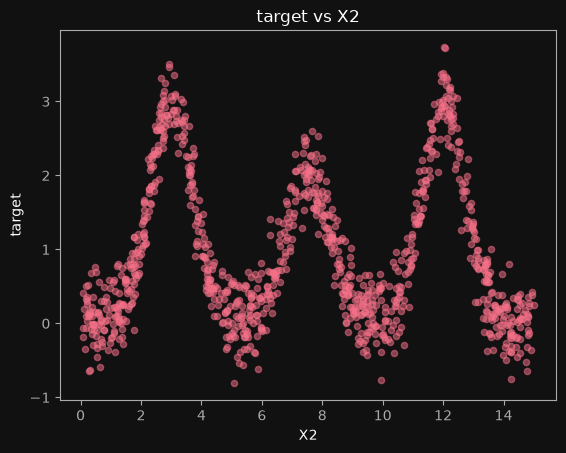

In [6]:
ax = df.plot.scatter(x="X2", y="target", alpha=0.5, title="target vs X2")
ax.figure.savefig("./figures/problem2_scatter.png", dpi=300, bbox_inches="tight")

### 2.2

In [7]:
def knn_regressor(
    X_train: NDArray[np.float64],
    y_train: NDArray[np.float64],
    X_test: NDArray[np.float64],
    k: int,
) -> NDArray[np.float64]:
    """One test point at a time."""
    y_pred = []
    for x_test in X_test:
        distances = np.linalg.norm(X_train - x_test, axis=1)
        knn_indices = np.argsort(distances)[:k]
        y_pred.append(np.mean(y_train[knn_indices]))
    return np.array(y_pred)


def knn_regressor_matrix(
    X_train: NDArray[np.float64],
    y_train: NDArray[np.float64],
    X_test: NDArray[np.float64],
    k: int,
) -> NDArray[np.float64]:
    """All test points at once, at the cost of an n_train x n_test matrix."""
    distances = np.linalg.norm(X_train[:, np.newaxis] - X_test[np.newaxis, :], axis=2)
    knn_indices = np.argsort(distances, axis=0)[:k, :]
    return np.mean(y_train[knn_indices], axis=0)

### 2.3

In [8]:
np.random.seed(42)

ind = df.index.to_numpy().copy()
np.random.shuffle(ind)
n = len(ind)
train_ind, test_ind = ind[: int(n * 0.8)], ind[int(n * 0.8) :]

X_train = df.loc[train_ind, ["X2"]].to_numpy()
X_test = df.loc[test_ind, ["X2"]].to_numpy()
y_train = df.loc[train_ind, "target"].to_numpy()
y_test = df.loc[test_ind, "target"].to_numpy()

y_pred = knn_regressor(X_train, y_train, X_test, k=5)
print(f"MSE at k=5: {((y_test - y_pred) ** 2).mean():.4f}")

MSE at k=5: 0.0996


In [9]:
# Check only: the two implementations must agree.
assert np.allclose(y_pred, knn_regressor_matrix(X_train, y_train, X_test, k=5))

### 2.4

\begin{tabular}{lr}
\toprule
 & MSE \\
\midrule
1 & 0.1838 \\
5 & 0.0996 \\
10 & 0.0939 \\
20 & 0.0926 \\
50 & 0.0995 \\
100 & 0.1740 \\
\bottomrule
\end{tabular}

minimum MSE 0.0926 at k=20


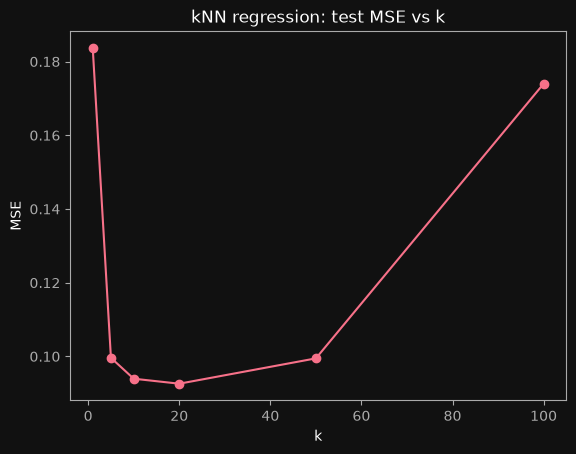

In [10]:
k_list = [1, 5, 10, 20, 50, 100]
mse = pd.Series(
    [((y_test - knn_regressor(X_train, y_train, X_test, k=k)) ** 2).mean() for k in k_list],
    index=k_list,
    name="MSE",
)
ax = mse.plot(marker="o", xlabel="k", ylabel="MSE", title="kNN regression: test MSE vs k")
ax.figure.savefig("./figures/problem2_mse_vs_k.png", dpi=300, bbox_inches="tight")
print(mse.to_latex(float_format="{:0.4f}".format))
print(f"minimum MSE {mse.min():.4f} at k={mse.idxmin()}")

### 2.5

Written answer only; see the write-up.

## Problem 3

### 3.1

In [11]:
import statsmodels.api as sm

X3, y = df["X3"], df["y"]
print(sm.OLS(y, X3).fit().params)

X3    0.564234
dtype: float64


### 3.2

In [12]:
model_3_2 = sm.OLS(y, sm.add_constant(X3)).fit()
print(model_3_2.params)
print(f"R^2 = {model_3_2.rsquared:.4f}")

const    7.151452
X3      -0.292625
dtype: float64
R^2 = 0.1707


### 3.3

In [13]:
print(sm.OLS(y - y.mean(), X3 - X3.mean()).fit().params)

X3   -0.292625
dtype: float64


### 3.4

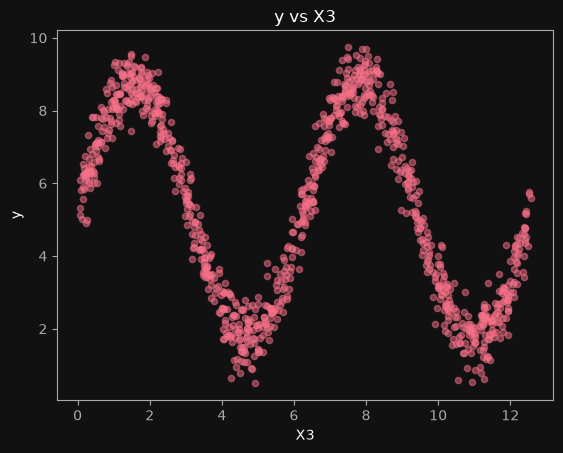

In [14]:
ax = df.plot.scatter(x="X3", y="y", alpha=0.5, title="y vs X3")
ax.figure.savefig("./figures/problem3_scatter.png", dpi=300, bbox_inches="tight")

### 3.5

In [15]:
df["X3_sin"] = np.sin(df["X3"])
model_3_5 = sm.OLS(y, sm.add_constant(df["X3_sin"])).fit()
print(model_3_5.params)
print(f"R^2 = {model_3_5.rsquared:.4f}")

const     5.248421
X3_sin    3.536209
dtype: float64
R^2 = 0.9639


### 3.6

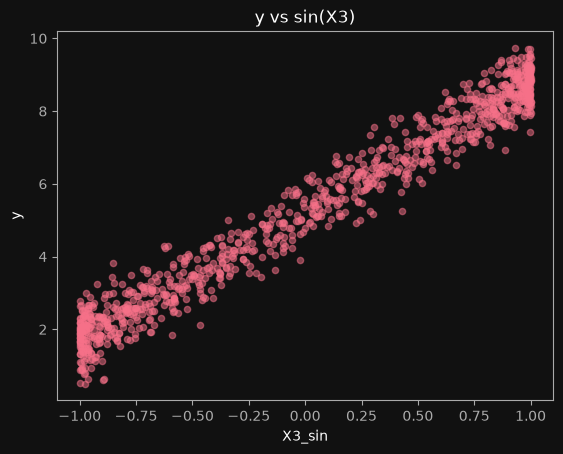

In [16]:
ax = df.plot.scatter(x="X3_sin", y="y", alpha=0.5, title="y vs sin(X3)")
ax.figure.savefig("./figures/problem3_scatter_sin.png", dpi=300, bbox_inches="tight")